In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, zscore, spearmanr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import joblib

In [3]:
root = Path.cwd().parent 
data_path = root / "Real Data" / "log2.csv"
df = pd.read_csv(data_path)
df.head()

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18


In [3]:
action_mapping = {
    'allow': 0,
    'deny': 1,
    'drop': 2,
    'reset-both': 3
}
df['Action'] = df['Action'].map(action_mapping)

df.drop_duplicates()

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,0,177,94,83,2,30,1,1
1,56258,3389,56258,3389,0,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,0,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,0,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,0,25358,6778,18580,31,16,13,18
...,...,...,...,...,...,...,...,...,...,...,...,...
65526,51710,43069,65147,43069,0,70,70,0,2,8,2,0
65527,63691,80,13237,80,0,314,192,122,6,15,4,2
65528,50964,80,13485,80,0,4680740,67312,4613428,4675,77,985,3690
65529,54871,445,0,0,2,70,70,0,1,0,1,0


Action
0    37640
1    14987
2    12851
3       54
Name: count, dtype: int64
Action
0    57.44
1    22.87
2    19.61
3     0.08
Name: count, dtype: float64


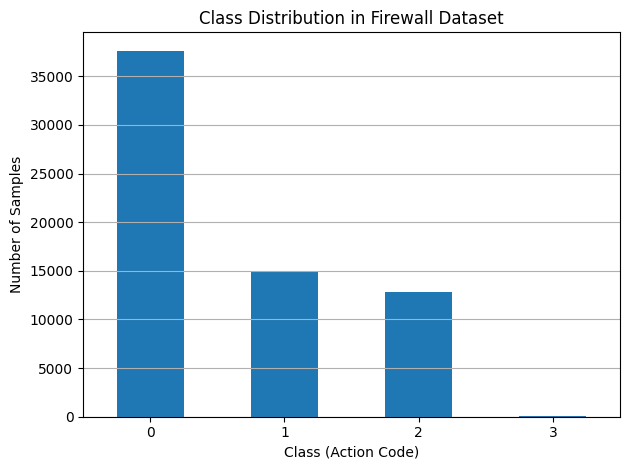

In [4]:
class_counts = df['Action'].value_counts().sort_index()
print(class_counts)

class_percentages = class_counts / len(df) * 100
print(class_percentages.round(2))

class_counts.plot(kind='bar')
plt.title('Class Distribution in Firewall Dataset')
plt.xlabel('Class (Action Code)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [20]:
exclude_columns = [
    'Action',
    'Source Port',
    'Destination Port',
    'NAT Source Port',
    'NAT Destination Port'
]

numerical_cols = df.select_dtypes(include=[np.number]).columns.difference(exclude_columns).tolist()

In [6]:
desc_stats = pd.DataFrame({
    'mean': df[numerical_cols].mean(),
    'median': df[numerical_cols].median(),
    'std': df[numerical_cols].std(),
    'min': df[numerical_cols].min(),
    'max': df[numerical_cols].max(),
    'skew': df[numerical_cols].apply(skew),
    'kurtosis': df[numerical_cols].apply(kurtosis)
}).round(3)

print(desc_stats)

                           mean   median          std  min         max  \
Bytes                 97123.950    168.0  5618438.909   60  1269359015   
Bytes Received        74738.153     79.0  2463207.712    0   320881795   
Bytes Sent            22385.797     90.0  3828138.650   60   948477220   
Destination Port      10577.386    445.0    18466.027    0       65535   
Elapsed Time (sec)       65.834     15.0      302.462    0       10824   
NAT Destination Port   2671.050     53.0     9739.162    0       65535   
NAT Source Port       19282.973   8820.5    21970.690    0       65535   
Packets                 102.866      2.0     5133.002    1     1036116   
Source Port           49391.969  53776.5    15255.713    0       65534   
pkts_received            61.467      1.0     2223.332    0      327208   
pkts_sent                41.400      1.0     3218.871    1      747520   

                         skew   kurtosis  
Bytes                 187.281  40466.966  
Bytes Received         93

In [11]:
z_scores = np.abs(zscore(df[numerical_cols], nan_policy='omit'))
outliers = (z_scores > 3)

outlier_summary = pd.DataFrame(outliers, columns=numerical_cols).sum().sort_values(ascending=False)
outlier_summary = outlier_summary[outlier_summary > 0].to_frame(name='outlier_count')

outlier_summary['percentage'] = (outlier_summary['outlier_count'] / len(df) * 100).round(5)

print("Outlier Summary (Z-score > 3):")
print(outlier_summary)

Outlier Summary (Z-score > 3):
               outlier_count  percentage
pkts_sent                902     1.37643
Packets                  639     0.97510
Bytes Sent               564     0.86065
Bytes                    490     0.74773
pkts_received            343     0.52341


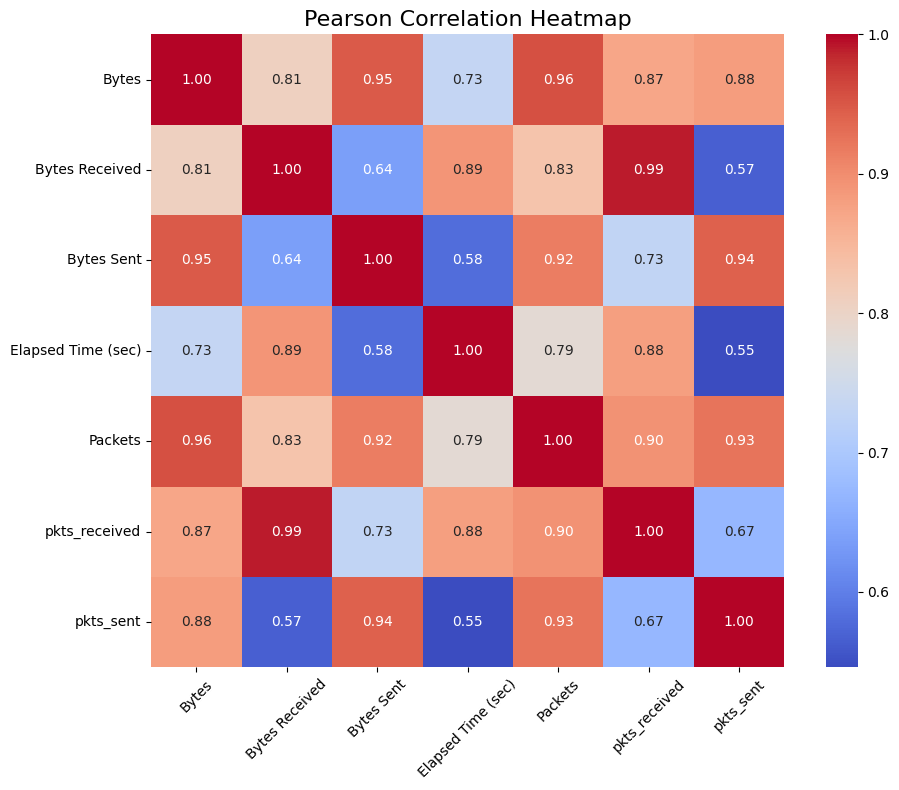

In [21]:
#df[numerical_cols] = df[numerical_cols].apply(lambda x: np.log1p(x))

# Compute Pearson correlation
pearson_corr = df[numerical_cols].corr(method='pearson')

# Plot single heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, cmap='coolwarm', annot=True, fmt=".2f", square=True, cbar=True,
            annot_kws={"size": 10})
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

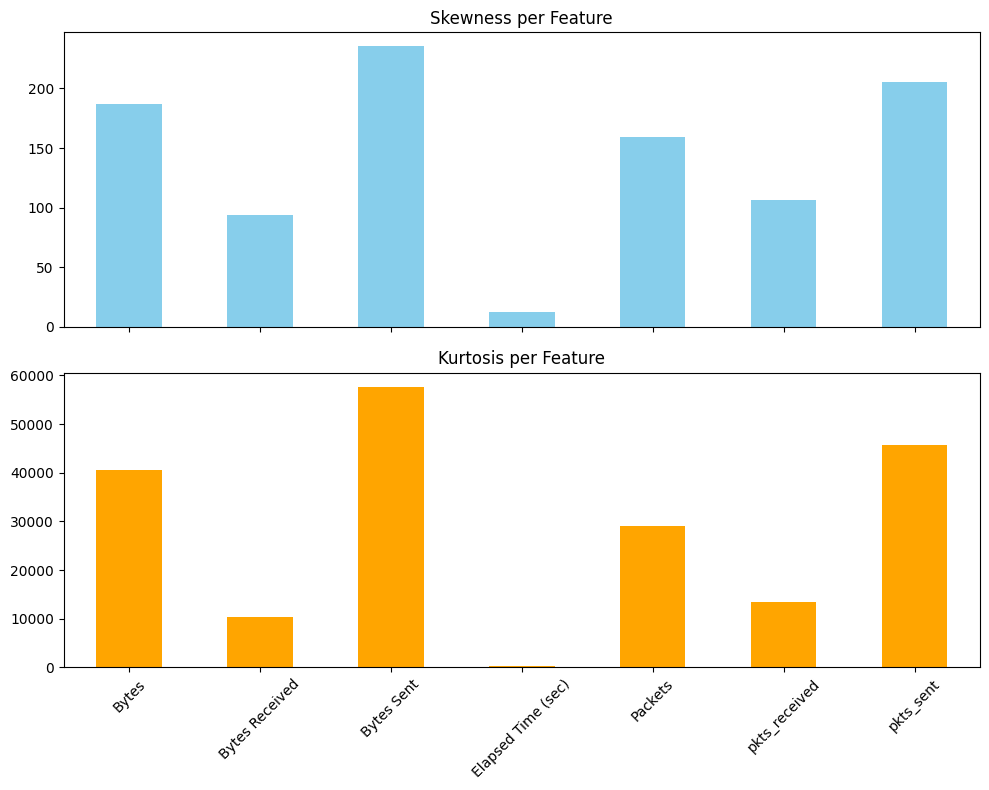

In [8]:
# Calculate skew and kurtosis
stats = pd.DataFrame({
    'Skewness': df[numerical_cols].apply(skew),
    'Kurtosis': df[numerical_cols].apply(kurtosis)
})

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Skewness plot
stats['Skewness'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Skewness per Feature')

# Kurtosis plot
stats['Kurtosis'].plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Kurtosis per Feature')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
